# Spiffyplots MultiPanel demo

This notebook introduces `MultiPanel` grid layouts, automatic panel labels, custom label styling, and label-array layouts.

In [17]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from spiffyplots import MultiPanel
from spiffyplots import populate_random_data

matplotlib.style.use("spiffy")

# Default figure size in centimeters
cm = 1 / 2.54
figsize = (12 * cm, 12 * cm)
seed = 0


## 1. Grid layouts

There are various ways of defining the shape of the `MultiPanel` grid layout.

#### 1.1 shape parameter (row, col) 

This leads to a `row` * `col` grid with equal panel sizes

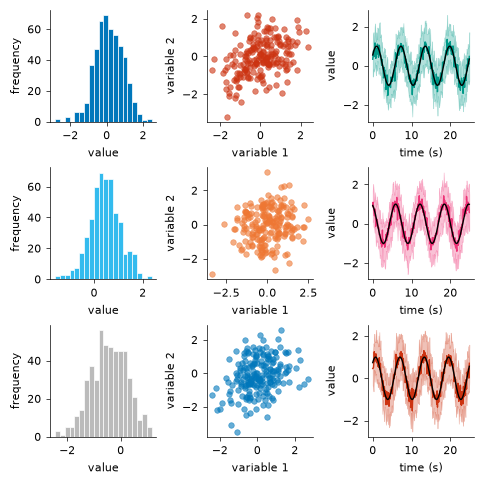

In [18]:
shape_grid = (3, 3)
figure_grid = MultiPanel(shape=shape_grid, figsize=figsize)
populate_random_data(figure_grid.panels, seed=seed)

display(figure_grid.fig)
plt.close(figure_grid.fig)

#### 1.2 grid parameter [panels_in_row1, panels_in_row2, panels_in_row3]

The `grid` parameter instead allows a definition based on the number of panels in each row.
The height of each row can additionally be determined by the `height_ratios` parameter.

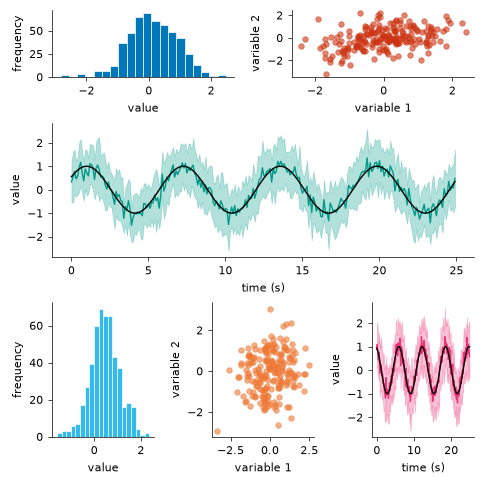

In [19]:
grid_mixed = [2, 1, 3]
figure_mixed = MultiPanel(grid=grid_mixed, figsize=figsize, height_ratios=[1, 2, 2])
populate_random_data(figure_mixed.panels, seed=seed)

display(figure_mixed.fig)
plt.close(figure_mixed.fig)

## 2. Default and custom panel labels

`spiffyplots` can automatically draw figure labels. We use the same grid as above and set `labels=True`.

### Default labels

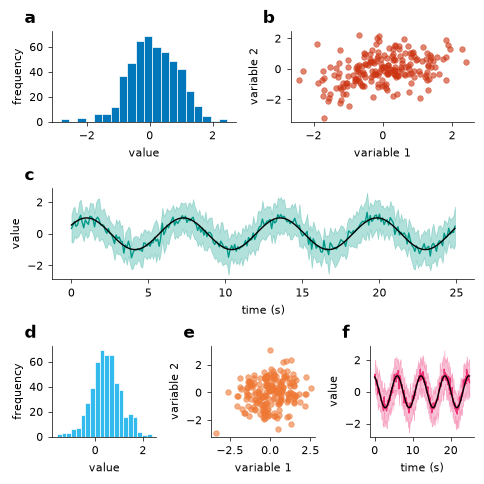

In [23]:
figure_labels_default = MultiPanel(
    grid=grid_mixed,
    figsize=figsize,
    labels=True,
)
populate_random_data(figure_labels_default.panels, seed=seed)

display(figure_labels_default.fig)
plt.close(figure_labels_default.fig)

### Custom labels

Custom label names can be combined with an offset measured in points, a different font size, and a different weight.

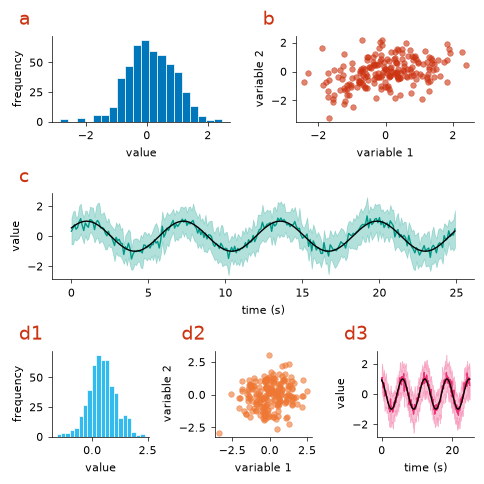

In [21]:
labels_custom = ("a", "b", "c", "d1", "d2", "d3")
label_offset_custom = (-24, 8)  # points from each panel's top-left corner
label_size_custom = 14
label_weight_custom = "normal"
color_labels = plt.rcParams["axes.prop_cycle"].by_key()["color"][1]

figure_labels_custom = MultiPanel(
    grid=grid_mixed,
    figsize=figsize,
    labels=labels_custom,
    label_offset=label_offset_custom,
    label_size=label_size_custom,
    label_weight=label_weight_custom,
    label_color=color_labels,
)
populate_random_data(figure_labels_custom.panels, seed=seed)

display(figure_labels_custom.fig)
plt.close(figure_labels_custom.fig)

## 3. Label-array layouts and named access

Instead of a `grid` or `shape` parameter, a two-dimensional label array can also define the panel spans and names. Those names also become attributes on `figure.panels`.

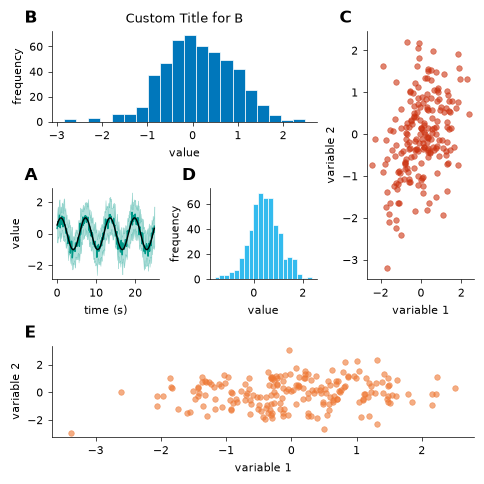

In [27]:
label_grid = np.array(
    [
        ["B", "B", "C"],
        ["A", "D", "C"],
        ["E", "E", "E"],
    ]
)
figure = MultiPanel(labels=label_grid, figsize=figsize)
populate_random_data(figure.panels, seed=seed)


# Access panels by their label 
figure.panels.B.set_title("Custom Title for B")

display(figure.fig)
plt.close(figure.fig)